In [125]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import glob 
import re 
import scienceplots
from astropy.coordinates import SkyCoord
import astropy.units as u
plt.style.use(['science', 'notebook', 'grid'])

In [110]:
def blockify_covariance(flat_cov, nsn):
    cov = np.zeros((nsn, nsn))
    idx = np.triu_indices(nsn)
    cov[idx] = flat_cov
    cov = cov + cov.T - np.diag(cov.diagonal())
    return cov
    

In [111]:
#url_cov = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov'
url_cov = 'https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov'
vals = np.loadtxt(url_cov)[1:]

pplus_cov = np.reshape(vals, (1701, 1701))

In [114]:
DES_PATH = '/user/animesh.sah/DES_analysis/DES-SN5YR'

des5yr = pd.read_csv(DES_PATH+'/4_DISTANCES_COVMAT/des_sn5yr.csv',sep='\s+',comment='#',header=0)
nsn = len(des5yr)
covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov']
nsn_covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['nsn']
assert nsn == nsn_covmat, f"Number of supernovae in metadata ({nsn}) does not match number in covariance matrix ({nsn_covmat})"
cov = blockify_covariance(covmat, nsn)

In [117]:
# print("cov shape:", cov.shape)
# print("symmetry:", np.max(np.abs(cov - cov.T)))

# eig = np.linalg.eigvalsh(cov)
# print("min eig:", eig.min())

# print("condition number:", np.linalg.cond(cov))
# from scipy import linalg
# COVd = linalg.inv(cov)

# print(np.max(np.abs(COVd - COVd.T)))

In [ ]:
eig_inv = np.linalg.eigvalsh(COVd)

print(eig_inv.min())

0.003678625029286112


In [118]:
# print(np.max(np.abs(cov - cov.T)))

# eig = np.linalg.eigvalsh(cov)

# print(eig.min())
# print(np.sum(eig <= 0))

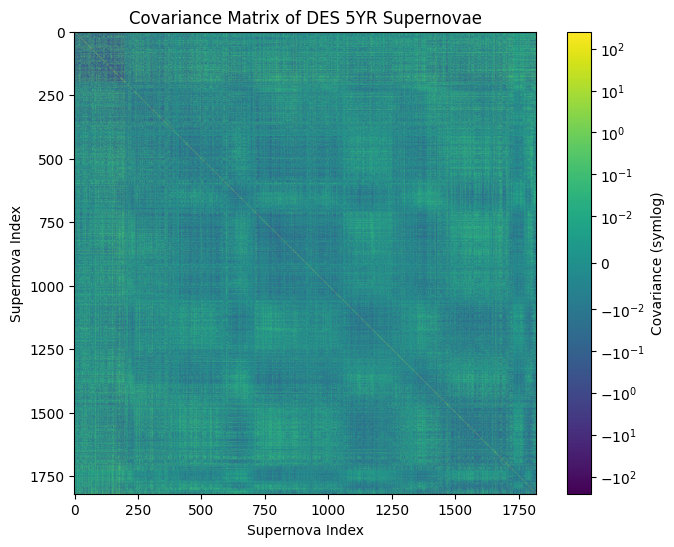

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(
    cov,
    cmap='viridis',
    norm=SymLogNorm(linthresh=1e-2, vmin=-np.max(np.abs(cov)), vmax=np.max(np.abs(cov)))
)
plt.colorbar(label='Covariance (symlog)')
plt.title('Covariance Matrix of DES 5YR Supernovae')
plt.xlabel('Supernova Index')
plt.ylabel('Supernova Index')
plt.show()

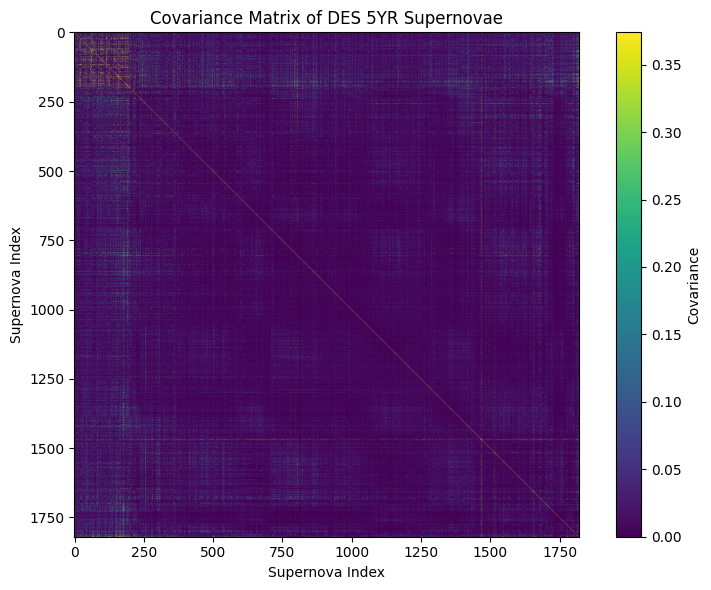

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(
    cov,
    cmap='viridis',
    vmin=-np.percentile(np.abs(cov), 0), 
    vmax=np.percentile(np.abs(cov), 99)
)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix of DES 5YR Supernovae')
plt.xlabel('Supernova Index')
plt.ylabel('Supernova Index')
plt.tight_layout()
plt.show()

In [119]:
cov_c_mB =  -2.5 * (des5yr['COV_c_x0'])/ np.log(10)/ des5yr['x0']
cov_x1_mB =  -2.5 * (des5yr['COV_x1_x0'])/ np.log(10)/ des5yr['x0']

sigma_mB = np.sqrt((2.5/(np.log(10)*des5yr['x0']))**2 * des5yr['x0ERR']**2)

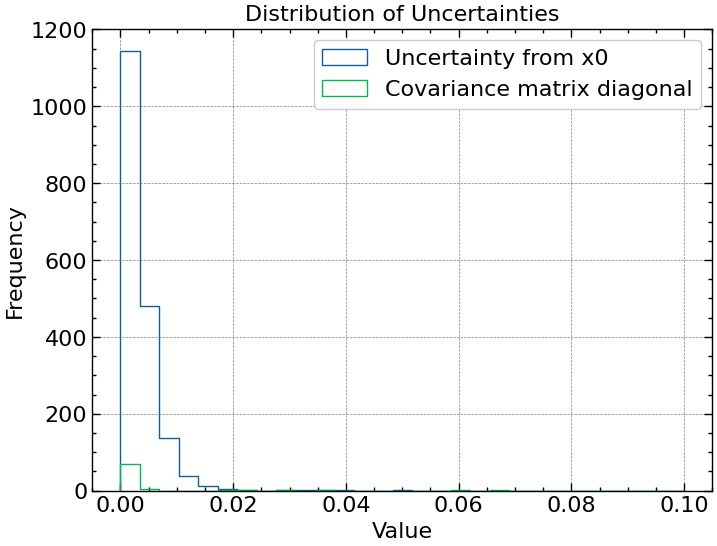

In [120]:
bins = np.linspace(0, 0.1, 30)
plt.hist(sigma_mB**2,bins=bins,histtype='step',label='Uncertainty from x0')
plt.hist(np.diag(cov),bins=bins,histtype='step',label='Covariance matrix diagonal')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Uncertainties')
plt.legend()
plt.show()

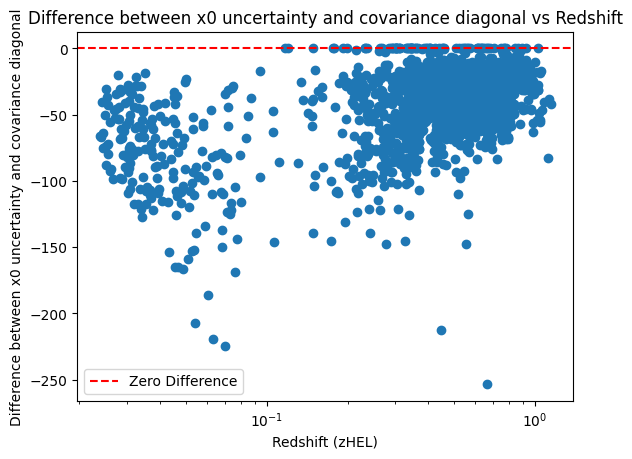

In [ ]:
plt.plot(des5yr['zHEL'],sigma_mB**2 -np.diag(cov) ,'o')
plt.xlabel('Redshift (zHEL)')
plt.ylabel('Difference between x0 uncertainty and covariance diagonal')
plt.title('Difference between x0 uncertainty and covariance diagonal vs Redshift')
plt.axhline(0, color='red', linestyle='--', label='Zero Difference')
plt.legend()
plt.xscale('log')
# plt.ylim(-1,2)


#plt.hist(np.diag(cov),bins=bins,histtype='step',label='Covariance matrix diagonal')

In [ ]:
cov_3n3n= np.zeros((3*nsn,3*nsn))

cov_3n3n[::3,::3] = cov

idx = np.arange(1, 3*nsn, 3)
cov_3n3n[idx, idx] = des5yr['x1ERR']**2
idx = np.arange(2, 3*nsn, 3)
cov_3n3n[idx, idx] = des5yr['cERR']**2
idx = np.arange(0, 3*nsn, 3)
idx2 = idx+1
cov_3n3n[idx, idx2] = cov_x1_mB
cov_3n3n[idx2, idx] = cov_x1_mB
idx2 = idx+2
cov_3n3n[idx, idx2] = cov_c_mB
cov_3n3n[idx2, idx] = cov_c_mB
idx = np.arange(1, 3*nsn, 3)
idx2 = idx+1
cov_3n3n[idx, idx2] = des5yr['COV_x1_c']
cov_3n3n[idx2, idx] = des5yr['COV_x1_c']

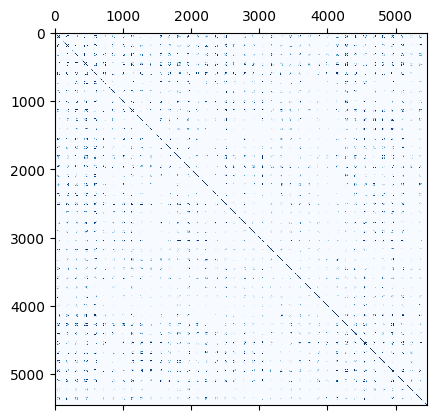

In [47]:
plt.matshow(cov_3n3n, cmap='Blues', vmin=-np.percentile(np.abs(cov_3n3n), 0), vmax=np.percentile(np.abs(cov_3n3n), 99))

Individual systematics

In [170]:
statsys = np.linalg.inv(blockify_covariance(np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov'], nsn))
stat = np.linalg.inv(blockify_covariance(np.load(DES_PATH+'/4_DISTANCES_COVMAT/STATONLY.npz')['cov'], nsn))
sys = statsys - stat


In [176]:
np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov']

array([ 3.0984404e+01, -4.5414665e-03,  4.1780461e-02, ...,
        3.8469845e+01, -1.4177059e+00,  4.1719524e+01], dtype=float32)

In [ ]:
np.duastatsys

219034.1211251511

In [8]:
np.diag(statsys)

array([0.0346064 , 0.02865698, 0.01890931, ..., 0.01581458, 0.03770404,
       0.02801165])

In [9]:
single_sys_cov={}
single_sys = glob.glob(DES_PATH+'/4_DISTANCES_COVMAT/SingleSYS_CovMatrix/*.npz')


In [29]:
from scipy.linalg import cho_factor, cho_solve
def precision_to_covariance(P):
    c, lower = cho_factor(P, overwrite_a=False, check_finite=False)
    I = np.eye(P.shape[0], dtype=P.dtype)
    C = cho_solve((c, lower), I, check_finite=False)
    return C



In [36]:
for sys_file in single_sys:
    sys_name = re.search(r'SingleSYS_CovMatrix/(.*)\.npz', sys_file).group(1)
    single_sys_cov[sys_name] = precision_to_covariance(blockify_covariance(np.load(sys_file)['cov'], nsn))

In [83]:
sys_cov_added = np.zeros((nsn, nsn))
for sys_name, cov_matrix in single_sys_cov.items():
    #plt.figure(figsize=(8, 6))
    #bins = np.linspace(np.percentile(np.diag(cov_matrix-stat), 0.01), np.percentile(np.diag(cov_matrix-stat), 98), 50)
    # plt.hist(np.diag(cov_matrix-stat), bins=bins,alpha = 0.8)
    # plt.ylabel('Frequency')
    # plt.xlabel('Covariance Diagonal Value')
    # plt.title(f'Distribution of Diagonal Values for {sys_name} Covariance Matrix')
    # plt.show()
    sys_cov_added += cov_matrix-stat


In [84]:
# for sys_name, cov_matrix in single_sys_cov.items():
#     plt.figure(figsize=(8, 6))
#     bins = np.linspace(np.percentile(np.diag(cov_matrix), 0.1), np.percentile(np.diag(cov_matrix), 95), 50)
#     plt.hist(np.diag(cov_matrix), bins=bins,alpha = 0.8)
#     plt.ylabel('Frequency')
#     plt.xlabel('Covariance Diagonal Value')
#     plt.title(f'Distribution of Diagonal Values for {sys_name} Covariance Matrix')
#     plt.show()

In [177]:
B = np.sum([Ck - stat for Ck in single_sys_cov.values()], axis=0)


In [178]:
np.linalg.norm(sys- B)/np.linalg.norm(sys)

0.0057359554378827666

In [181]:
print(np.max(np.abs(sys)))
print(np.mean(np.abs(sys)))

0.15905692802018925
0.0012225225027816817


In [182]:
D = sys-B
print(np.max(np.abs(D)))
print(np.mean(np.abs(D)))
print(np.median(np.abs(D)))

diag_ratio = (
    np.linalg.norm(np.diag(sys)-np.diag(B))
    /
    np.linalg.norm(np.diag(sys))
)

print(diag_ratio)

0.017021179279254284
3.2105368282640996e-06
1.0613039792291466e-06
0.04488366211128278


In [186]:
d = np.diag(sys) - np.diag(B)

# print(np.max(np.abs(d)))
# print(np.mean(np.abs(d)))
# print(np.median(np.abs(d)))
idx = np.argsort(np.abs(d))[-10:]

for i in idx:
    print(i, np.diag(sys)[i], np.diag(B)[i], d[i])

387 0.038188658432659395 0.03956951291002042 -0.0013808544773610265
694 0.010823064658325166 0.008750262364628725 0.0020728022936964408
338 0.07172359673131723 0.07403748796787113 -0.0023138912365539
375 0.005886944811209105 0.008399622409342555 -0.0025126775981334504
206 0.010541193107201252 0.007934884699352551 0.002606308407848701
477 0.007266063039423898 0.010272420237015467 -0.0030063571975915693
289 0.04234863756573759 0.03933766354020918 0.0030109740255284123
1386 0.010755601715038005 0.01462447850304853 -0.003868876788010525
981 0.010777713199786376 0.026990550293703564 -0.016212837093917187
1319 0.03759787932358449 0.05461905860283878 -0.017021179279254284


In [188]:
i = 1319

for name, Ck in single_sys_cov.items():
    d = np.diag(Ck - stat)
    print(name, d[i])
print('='*50)

i = 981

for name, Ck in single_sys_cov.items():
    d = np.diag(Ck - stat)
    print(name, d[i])

FIXED_AB 0.0021129891247255728
CAL_SALT3 0.002216185712313745
ZSHIFT 3.442983143031597e-08
BS21 0.0024309750442625955
GAMMAEVOL 1.0143019608221948e-05
SVAHOST 0.005224813852692023
P24a 0.00010557427594903857
SIGINT_MODEL 6.134439900051802e-06
SCONE 1.332300598733127e-07
SNN 3.125169314444065e-07
SNIRF 0.002136288851033896
W22 0.0001655392479733564
BETAEVOL 9.043644240591675e-06
VPEC 0.0
P24c 0.0002049911126960069
ALPHAEVOL 6.335903890430927e-08
MASSLOC 1.0245275916531682e-06
P24b 0.003022336335561704
INTRSC_COLOR 0.03272680749796564
CCPRIOR_H11 7.938069757074118e-09
MWEBV 0.002121183897543233
COLORLAW 3.387685865163803e-08
EFF_ZSPEC 0.0021223628718871623
CALSPEC 2.0797961042262614e-06
FIXED_AB 2.856540959328413e-08
CAL_SALT3 0.0041246359833166935
ZSHIFT 7.748894859105349e-09
BS21 0.005876400857232511
GAMMAEVOL 2.2837266442365944e-06
SVAHOST 0.00420118733018171
P24a 0.00016128733841469511
SIGINT_MODEL 6.497721187770367e-07
SCONE 1.4408942661248147e-06
SNN 3.6940982681699097e-06
SNIRF 1.

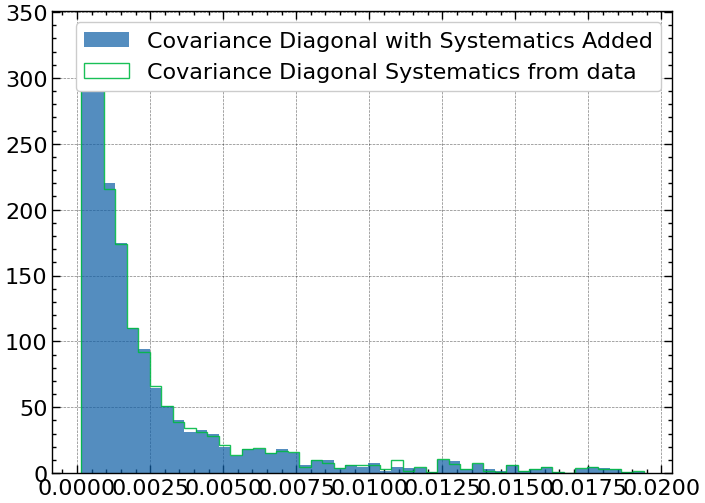

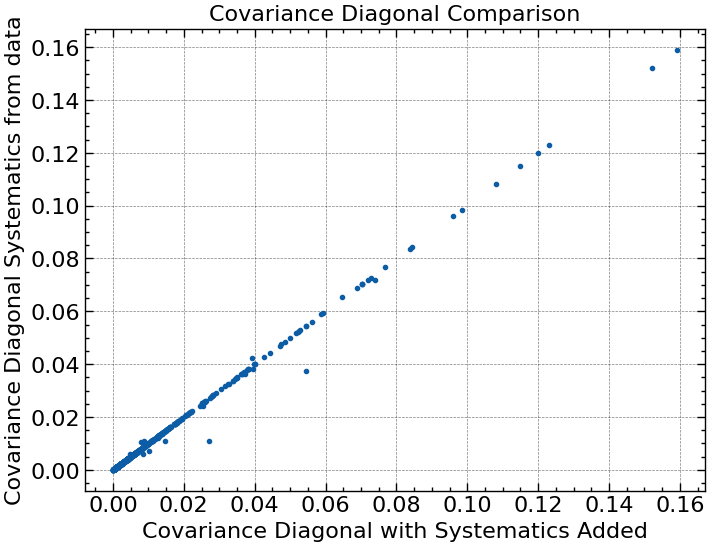

Text(0.5, 1.0, 'Covariance Comparison')

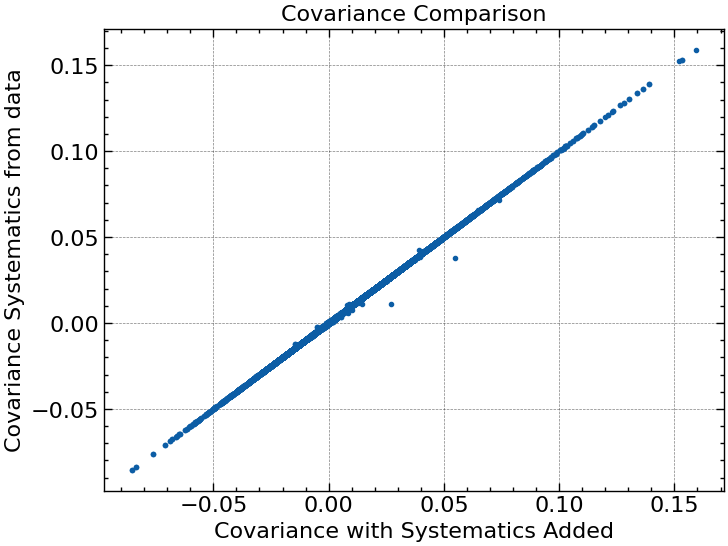

In [82]:
bins = np.linspace(np.percentile(np.diag(sys), 0.1), np.percentile(np.diag(sys), 95), 50)
plt.hist(np.diag(sys_cov_added),bins = bins,label = 'Covariance Diagonal with Systematics Added', alpha=0.7)
plt.hist(np.diag(sys),bins = bins,label = 'Covariance Diagonal Systematics from data', alpha=0.9, histtype='step')
plt.legend()
plt.show()
plt.plot(np.diag(sys_cov_added), np.diag(sys), '.')
plt.xlabel('Covariance Diagonal with Systematics Added')
plt.ylabel('Covariance Diagonal Systematics from data')
plt.title('Covariance Diagonal Comparison')
plt.show()

plt.plot(np.ravel(sys_cov_added), np.ravel(sys), '.')
plt.xlabel('Covariance with Systematics Added')
plt.ylabel('Covariance Systematics from data')
plt.title('Covariance Comparison')

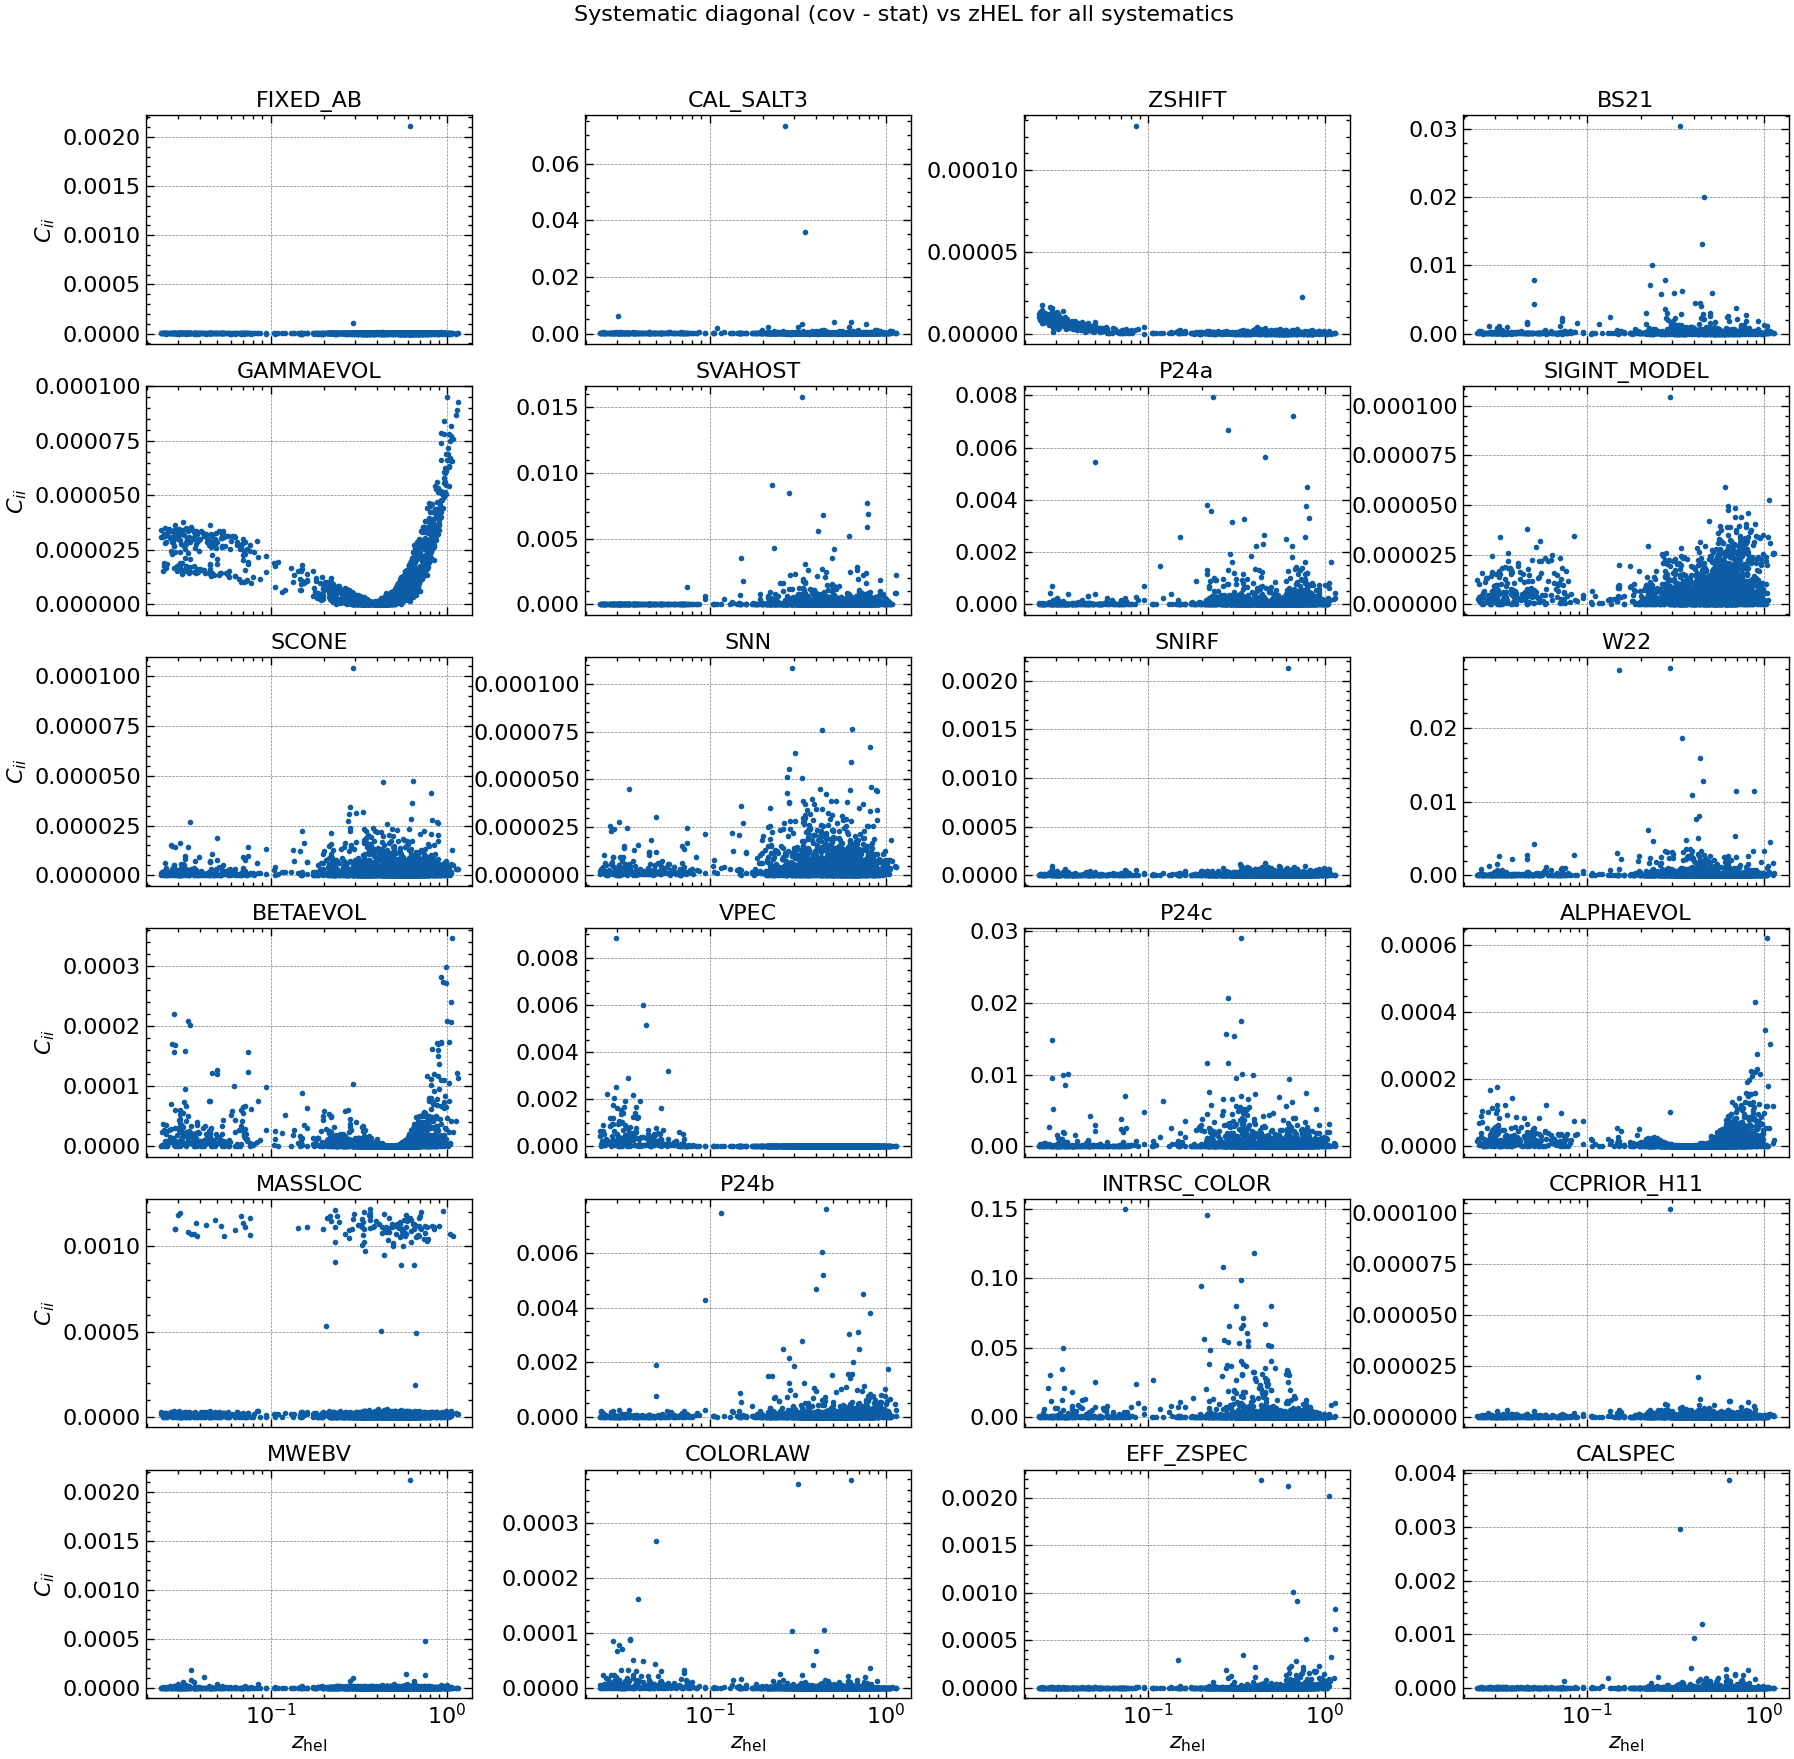

In [108]:
n_sys = len(keys)
ncols = 4
nrows = int(np.ceil(n_sys / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows), sharex=True)
axes = axes.flatten()

for i, name in enumerate(keys):
    cov_sys_minus_stat = single_sys_cov[name] - stat
    diag_vals = np.diag(cov_sys_minus_stat)
    ax = axes[i]
    ax.plot(des5yr['zHEL'], diag_vals, 'o', ms=3)
    ax.set_xscale('log')
    ax.set_title(name)
    if i % ncols == 0:
        ax.set_ylabel('$C_{ii}$')
    if i >= n_sys - ncols:
        ax.set_xlabel('$z_{\\rm hel}$')

# hide any unused subplots
for j in range(n_sys, len(axes)):
    axes[j].axis('off')

fig.suptitle('Systematic diagonal (cov - stat) vs zHEL for all systematics', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Text(0, 0.5, 'Supernova Index')

<Figure size 1000x800 with 0 Axes>

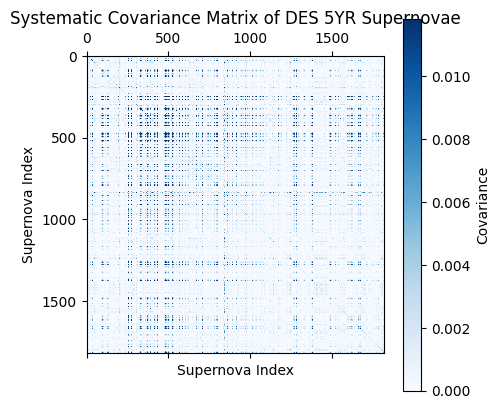

In [26]:
plt.figure(figsize=(10, 8))
plt.matshow(sys, cmap='Blues', vmin=-np.percentile(np.abs(sys), 0), vmax=np.percentile(np.abs(sys), 99))
plt.colorbar(label='Covariance')
plt.title('Systematic Covariance Matrix of DES 5YR Supernovae')
plt.xlabel('Supernova Index')
plt.ylabel('Supernova Index')


In [169]:
np.diag(np.linalg.inv(statsys)).min(), np.diag(np.linalg.inv(statsys)).max()

(4.565498784359082e-06, 253.6373748779304)

In [168]:
np.diag(statsys).min(), np.diag(statsys).max()

(0.005374032663128353, 219034.1211251511)

In [152]:

plt.rcParams['figure.figsize'] = [9, 6]
plt.rcParams['figure.dpi'] = 80
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

def plot_oneset(ax, RA, Dec, org=0, title='Mollweide projection', projection='mollweide', color=None, size=2.0, marker='o', fillstyle='full', globalparam=1, line=False, alpha=0.8, l1='Marker', ar='None', cmmap=False, vmin=None, vmax=None, val=None, edgecolors=None, ls='-', fill=False,label='Peculliar velocity',cmap='jet'):
    x = np.remainder(RA + 360 - org, 360)  # shift RA values
    ind = x > 180
    x[ind] -= 360  # scale conversion to [-180, 180]
    x = -x  # reverse the scale: East to the left

    segments = []
    current_segment = []
    for xi, di in zip(x, Dec):
        if current_segment and abs(xi - current_segment[-1][0]) > 180:
            segments.append(current_segment)
            current_segment = []
        current_segment.append((xi, di))
    if current_segment:
        segments.append(current_segment)
    i=0
    for segment in segments:
        seg_x, seg_dec = zip(*segment)
        if not line:
            if cmmap:
                if vmin is None and vmax is None:
                    sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), c=val, alpha=alpha, cmap=cmap, s=size, marker=marker, label=l1)
                else:
                    sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), c=val, alpha=alpha, cmap=cmap, s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax)
                ax.set_xlabel('l', fontsize=20)
                ax.set_ylabel('b', fontsize=20)
                colorbar = plt.colorbar(sc, shrink=0.5)
                colorbar.set_label(label)
                colorbar.ax.yaxis.label.set_size(25)  # Adjust the font size as desired
            else:
                sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)
                ax.set_xlabel('$l$', fontsize=29)
                ax.set_ylabel('$b$', fontsize=29)
        else:
            if i==0:
                ax.plot(np.radians(seg_x), np.radians(seg_dec), alpha=0.8, color=color, lw=2, ls=ls, label=l1)
            else:
                ax.plot(np.radians(seg_x), np.radians(seg_dec), alpha=0.8, color=color, lw=2, ls=ls)
            i+=1
vcmb=369.82 #km/s
c=299792.458
racmb=167.942
deccmb=-6.944
gal_cmb =SkyCoord(ra=racmb* u.deg, dec=deccmb* u.deg, frame='icrs').galactic

/tmp/ipykernel_1479865/2094786468.py:36: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)


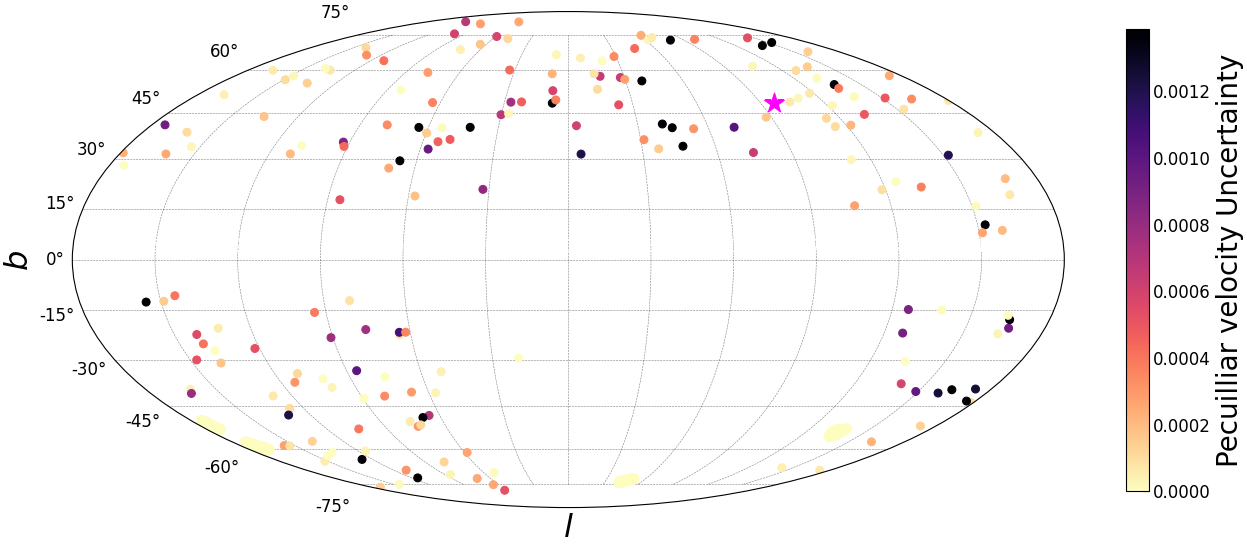

In [156]:
dict2={}
dict1={}

org = 0
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])

tick_labels = np.remainder(tick_labels+360+org,360)

fig = plt.figure(figsize=(20, 15))
#ax.plot(galpan.l.wrap_at('180d').radian, galpan.b.radian,"gv",ms=10,label='PAN+ (JLA $\cap$ PAN+)')

ax = fig.add_subplot(111, projection='mollweide')
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='x', colors='white')

#plot_oneset(ax, pplus['l'], pplus['b'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)

plot_oneset(ax, np.array([des5yr['l']]), [des5yr['b']], color='k', marker='.', size=200, fillstyle='none', line=False, alpha=1, l1=0,cmmap=True, val=np.array(np.diag(single_sys_cov['VPEC'] - stat)),label='Pecuilliar velocity Uncertainty',vmin=0, vmax = np.percentile(np.diag(single_sys_cov['VPEC'] - stat), 99),cmap='magma_r')
plot_oneset(ax, np.array([gal_cmb.l.value]), [gal_cmb.b.value], color='magenta', marker='*', size=350, fillstyle='none', line=False, alpha=1, l1=0, label='CMB dipole direction')

#plt.title(f'DES-SN5YR (zHEL<0.09): {len(subdata)} SNe Ia', fontsize=20)

/tmp/ipykernel_1479865/2094786468.py:36: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)


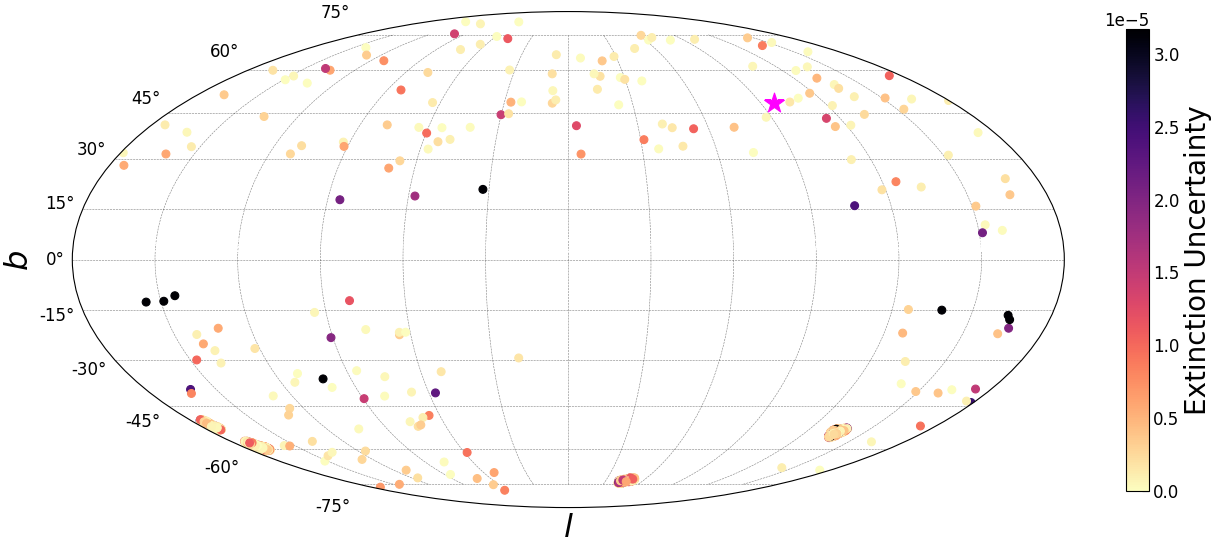

In [155]:
dict2={}
dict1={}

org = 0
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])

tick_labels = np.remainder(tick_labels+360+org,360)

fig = plt.figure(figsize=(20, 15))
#ax.plot(galpan.l.wrap_at('180d').radian, galpan.b.radian,"gv",ms=10,label='PAN+ (JLA $\cap$ PAN+)')

ax = fig.add_subplot(111, projection='mollweide')
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='x', colors='white')

#plot_oneset(ax, pplus['l'], pplus['b'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)

plot_oneset(ax, np.array([des5yr['l']]), [des5yr['b']], color='k', marker='.', size=200, fillstyle='none', line=False, alpha=1, l1=0,cmmap=True, val=np.array(np.diag(single_sys_cov['MWEBV'] - stat)),label='Extinction Uncertainty',vmin = 0, vmax = np.percentile(np.diag(single_sys_cov['MWEBV'] - stat), 99),cmap='magma_r')
plot_oneset(ax, np.array([gal_cmb.l.value]), [gal_cmb.b.value], color='magenta', marker='*', size=350, fillstyle='none', line=False, alpha=1, l1=0, label='CMB dipole direction')

#plt.title(f'DES-SN5YR (zHEL<0.09): {len(subdata)} SNe Ia', fontsize=20)

In [148]:
np.percentile(np.diag(single_sys_cov['MWEBV'] - stat), 99)

3.168140496599943e-05